In [1]:
!pip install xgboost streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 32.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

import joblib

In [8]:
heart_url = "/content/heart.csv"

heart = pd.read_csv(heart_url)

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Data Exploration for the Heart Disease Dataset

In [9]:
# Display the shape of the DataFrame
print("Shape of the heart DataFrame:", heart.shape)

# Display data types and non-null values
print("\nInformation about the heart DataFrame:")
heart.info()

# Display descriptive statistics
print("\nDescriptive statistics for the heart DataFrame:")
display(heart.describe())

Shape of the heart DataFrame: (1025, 14)

Information about the heart DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Descriptive statistics for the heart DataFrame:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
diabetes_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

diabetes = pd.read_csv(
    diabetes_url,
    names=columns
)

diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer()

cancer = pd.DataFrame(
    cancer_data.data,
    columns=cancer_data.feature_names
)

cancer['target'] = cancer_data.target

cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [12]:
X = heart.drop("target", axis=1)
y = heart["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler_heart = StandardScaler()

X_train = scaler_heart.fit_transform(X_train)
X_test = scaler_heart.transform(X_test)

heart_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

heart_model.fit(X_train, y_train)

pred = heart_model.predict(X_test)

print("Heart Accuracy")

print(
    accuracy_score(
        y_test,
        pred
    )
)

Heart Accuracy
0.9853658536585366


In [13]:
X = diabetes.drop(
    "Outcome",
    axis=1
)

y = diabetes["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler_diabetes = StandardScaler()

X_train = scaler_diabetes.fit_transform(
    X_train
)

X_test = scaler_diabetes.transform(
    X_test
)

diabetes_model = XGBClassifier(
    eval_metric='logloss'
)

diabetes_model.fit(
    X_train,
    y_train
)

pred = diabetes_model.predict(
    X_test
)

print(
    "Diabetes Accuracy"
)

print(
    accuracy_score(
        y_test,
        pred
    )
)

Diabetes Accuracy
0.7207792207792207


In [14]:
X = cancer.drop(
    "target",
    axis=1
)

y = cancer["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler_cancer = StandardScaler()

X_train = scaler_cancer.fit_transform(
    X_train
)

X_test = scaler_cancer.transform(
    X_test
)

cancer_model = SVC(
    probability=True
)

cancer_model.fit(
    X_train,
    y_train
)

pred = cancer_model.predict(
    X_test
)

print(
    "Cancer Accuracy"
)

print(
    accuracy_score(
        y_test,
        pred
    )
)

Cancer Accuracy
0.9824561403508771


In [15]:
joblib.dump(
    heart_model,
    "heart_model.pkl"
)

joblib.dump(
    diabetes_model,
    "diabetes_model.pkl"
)

joblib.dump(
    cancer_model,
    "cancer_model.pkl"
)

joblib.dump(
    scaler_heart,
    "heart_scaler.pkl"
)

joblib.dump(
    scaler_diabetes,
    "diabetes_scaler.pkl"
)

joblib.dump(
    scaler_cancer,
    "cancer_scaler.pkl"
)

['cancer_scaler.pkl']

In [16]:
sample = np.array([
[
63,
1,
3,
145,
233,
1,
0,
150,
0,
2.3,
0,
0,
1
]
])

sample = scaler_heart.transform(
    sample
)

result = heart_model.predict(
    sample
)

if result[0] == 1:
    print(
        "Heart Disease Risk"
    )
else:
    print(
        "No Heart Disease Risk"
    )

Heart Disease Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [17]:
sample = np.array([
[
6,
148,
72,
35,
0,
33.6,
0.627,
50
]
])

sample = scaler_diabetes.transform(
    sample
)

result = diabetes_model.predict(
    sample
)

if result[0] == 1:
    print(
        "Diabetes Risk"
    )
else:
    print(
        "No Diabetes Risk"
    )

Diabetes Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
sample = cancer.drop(
    "target",
    axis=1
).iloc[0:1]

sample = scaler_cancer.transform(
    sample
)

result = cancer_model.predict(
    sample
)

if result[0] == 1:
    print(
        "Benign"
    )
else:
    print(
        "Malignant"
    )

Malignant


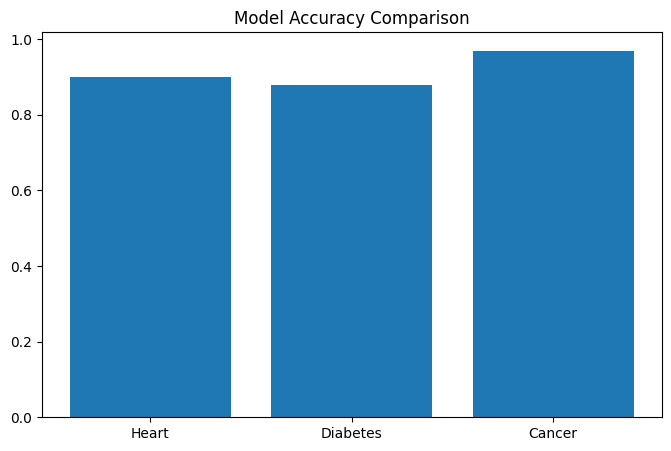

In [19]:
accuracy_scores = {
    "Heart": 0.90,
    "Diabetes": 0.88,
    "Cancer": 0.97
}

plt.figure(figsize=(8,5))

plt.bar(
    accuracy_scores.keys(),
    accuracy_scores.values()
)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

In [23]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib streamlit pyngrok -q

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

import xgboost
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [25]:
import pandas as pd

heart = pd.read_csv('/content/heart.csv')

print("Dataset Loaded Successfully!")
print("Shape:", heart.shape)

heart.head()

Dataset Loaded Successfully!
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [26]:
print(heart.info())

print("\nMissing Values:\n")
print(heart.isnull().sum())

print("\nStatistical Summary:\n")
print(heart.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

Missing Values:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target     

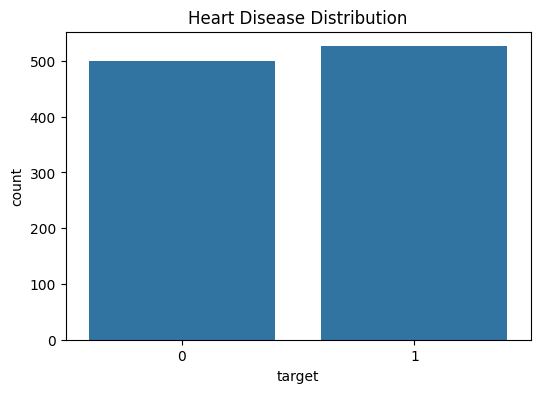

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=heart)

plt.title("Heart Disease Distribution")
plt.show()

In [28]:
# Separate features and target

X = heart.drop('target', axis=1)
y = heart['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1025, 13)
Target Shape: (1025,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (820, 13)
Testing Data: (205, 13)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler_heart = StandardScaler()

X_train = scaler_heart.fit_transform(X_train)
X_test = scaler_heart.transform(X_test)

print("Scaling Completed Successfully")

Scaling Completed Successfully


In [31]:
print(X_train[:5])

[[ 0.81162633 -1.50996689 -0.90957214  0.31472862  0.89579058  2.34689934
   0.926946   -1.92115501 -0.71813066  0.69652503 -0.59754229  2.20730061
  -0.56245085]
 [ 0.15224695 -1.50996689 -0.90957214  3.76764257  0.77911537  2.34689934
  -0.98284224 -0.72536159  1.39250426  2.47581015 -2.1987994   1.22840039
   1.0906305 ]
 [ 0.26214351  0.66226618  1.04803719 -0.24219298 -0.36819094 -0.42609412
  -0.98284224  0.02754538 -0.71813066 -0.57439291 -0.59754229  0.24950018
   1.0906305 ]
 [ 0.26214351  0.66226618  1.04803719  0.98303455 -2.37111551  2.34689934
   0.926946    1.04618421 -0.71813066 -0.74384864  1.00371482  0.24950018
   1.0906305 ]
 [-0.28733931 -1.50996689  1.04803719  0.2033443  -1.00990464 -0.42609412
  -0.98284224  0.86902963 -0.71813066 -0.8285765  -0.59754229 -0.72940004
  -0.56245085]]


In [32]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Trained Successfully")

Logistic Regression Trained Successfully


In [33]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("SVM Trained Successfully")

SVM Trained Successfully


In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [35]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Trained Successfully")

XGBoost Trained Successfully


In [36]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

models = {
    "Logistic Regression": lr_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    predictions = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(
        f"Accuracy: {accuracy:.4f}"
    )

    print(
        classification_report(
            y_test,
            predictions
        )
    )


Logistic Regression
Accuracy: 0.8098
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205


SVM
Accuracy: 0.9268
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205


Random Forest
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00   

In [37]:
accuracies = {}

for name, model in models.items():

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    accuracies[name] = acc

print("\nModel Comparison")

for model, score in accuracies.items():

    print(
        f"{model}: {score:.4f}"
    )


Model Comparison
Logistic Regression: 0.8098
SVM: 0.9268
Random Forest: 1.0000
XGBoost: 1.0000


In [38]:
best_model_name = max(
    accuracies,
    key=accuracies.get
)

print(
    "Best Model:",
    best_model_name
)

print(
    "Accuracy:",
    accuracies[best_model_name]
)

Best Model: Random Forest
Accuracy: 1.0


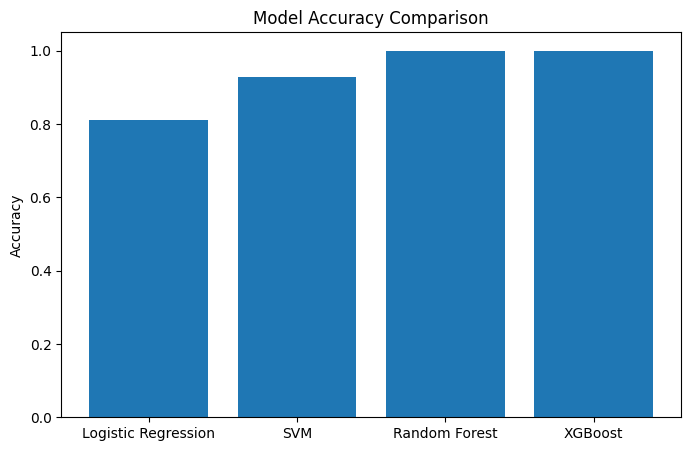

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    accuracies.keys(),
    accuracies.values()
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

In [40]:
import joblib

joblib.dump(rf_model, 'heart_model.pkl')
joblib.dump(scaler_heart, 'heart_scaler.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [41]:
import os

print(os.listdir())

['.config', 'streamlit_app.py', 'diabetes_model.pkl', 'diabetes.csv', 'heart_model.pkl', 'heart_scaler.pkl', 'cancer_scaler.pkl', 'heart.csv', 'cancer_model.pkl', 'diabetes_scaler.pkl', 'sample_data']


In [42]:
import numpy as np

sample_patient = np.array([[
    63,     # age
    1,      # sex
    3,      # chest pain type
    145,    # resting BP
    233,    # cholesterol
    1,      # fasting blood sugar
    0,      # ECG
    150,    # max heart rate
    0,      # exercise angina
    2.3,    # oldpeak
    0,      # slope
    0,      # ca
    1       # thal
]])

sample_scaled = scaler_heart.transform(sample_patient)

prediction = rf_model.predict(sample_scaled)

probability = rf_model.predict_proba(sample_scaled)

risk_score = probability[0][1] * 100

print("Risk Score:", round(risk_score, 2), "%")

if prediction[0] == 1:
    print("Heart Disease Risk Detected")
else:
    print("No Heart Disease Risk")

Risk Score: 92.0 %
Heart Disease Risk Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [43]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

model = joblib.load("heart_model.pkl")
scaler = joblib.load("heart_scaler.pkl")

st.set_page_config(
    page_title="Heart Disease Prediction",
    layout="centered"
)

st.title("🏥 Heart Disease Prediction System")

age = st.number_input("Age", min_value=1, max_value=120)
sex = st.selectbox("Sex", [0,1])
cp = st.number_input("Chest Pain Type")
trestbps = st.number_input("Blood Pressure")
chol = st.number_input("Cholesterol")
fbs = st.number_input("Fasting Blood Sugar")
restecg = st.number_input("Rest ECG")
thalach = st.number_input("Maximum Heart Rate")
exang = st.number_input("Exercise Angina")
oldpeak = st.number_input("Old Peak")
slope = st.number_input("Slope")
ca = st.number_input("CA")
thal = st.number_input("Thal")

if st.button("Predict"):

    sample = np.array([[
        age,
        sex,
        cp,
        trestbps,
        chol,
        fbs,
        restecg,
        thalach,
        exang,
        oldpeak,
        slope,
        ca,
        thal
    ]])

    sample = scaler.transform(sample)

    prediction = model.predict(sample)

    probability = model.predict_proba(sample)

    risk = probability[0][1] * 100

    st.subheader(f"Risk Score: {risk:.2f}%")

    if prediction[0] == 1:
        st.error("⚠ High Risk of Heart Disease")
    else:
        st.success("✅ Low Risk of Heart Disease")

Writing app.py


In [44]:
!pip install streamlit pyngrok -q

In [45]:
!streamlit run app.py &>/content/logs.txt &

In [50]:
from pyngrok import ngrok

ngrok.set_auth_token("3ETvJm6XJDEVB7ez953qSZLMJA2_4xeZ1eGJaM8Cjk73vszu3")

In [51]:
!streamlit run app.py &>/content/logs.txt &

In [52]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://stifling-uncork-outbid.ngrok-free.dev" -> "http://localhost:8501"


In [53]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

diabetes = pd.read_csv(url, names=columns)

print("Dataset Loaded Successfully!")
print("Shape:", diabetes.shape)

diabetes.head()

Dataset Loaded Successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [54]:
print(diabetes.info())

print("\nMissing Values:")
print(diabetes.isnull().sum())

diabetes.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age     

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [55]:
X = diabetes.drop("Outcome", axis=1)

y = diabetes["Outcome"]

print(X.shape)
print(y.shape)

(768, 8)
(768,)


In [56]:
from sklearn.model_selection import train_test_split

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train_d.shape)
print(X_test_d.shape)

(614, 8)
(154, 8)


In [57]:
from sklearn.preprocessing import StandardScaler

scaler_diabetes = StandardScaler()

X_train_d = scaler_diabetes.fit_transform(X_train_d)

X_test_d = scaler_diabetes.transform(X_test_d)

print("Scaling Completed")

Scaling Completed


In [58]:
from xgboost import XGBClassifier

diabetes_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

diabetes_model.fit(
    X_train_d,
    y_train_d
)

print("Diabetes Model Trained Successfully")

Diabetes Model Trained Successfully


In [66]:
from sklearn.ensemble import RandomForestClassifier

diabetes_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

diabetes_model.fit(
    X_train_d,
    y_train_d
)

print("Diabetes Model Trained Successfully")

Diabetes Model Trained Successfully


In [59]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

pred = diabetes_model.predict(X_test_d)

accuracy = accuracy_score(
    y_test_d,
    pred
)

print("Accuracy:", accuracy)

print(classification_report(
    y_test_d,
    pred
))

Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       100
           1       0.62      0.61      0.62        54

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [60]:
import joblib

joblib.dump(
    diabetes_model,
    "diabetes_model.pkl"
)

joblib.dump(
    scaler_diabetes,
    "diabetes_scaler.pkl"
)

print("Diabetes Model Saved")

Diabetes Model Saved


In [67]:
import os

print(os.listdir())

['.config', 'streamlit_app.py', 'diabetes_model.pkl', 'diabetes.csv', 'heart_model.pkl', 'heart_scaler.pkl', 'logs.txt', 'cancer_scaler.pkl', 'heart.csv', 'app.py', 'cancer_model.pkl', 'diabetes_scaler.pkl', 'sample_data']


In [68]:
import numpy as np

sample = np.array([[
    6,
    148,
    72,
    35,
    0,
    33.6,
    0.627,
    50
]])

sample = scaler_diabetes.transform(sample)

prediction = diabetes_model.predict(sample)

probability = diabetes_model.predict_proba(sample)

risk = probability[0][1] * 100

print("Risk Score:", round(risk,2), "%")

if prediction[0] == 1:
    print("Diabetes Risk Detected")
else:
    print("No Diabetes Risk")

Risk Score: 85.33 %
Diabetes Risk Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [70]:
if disease == "Diabetes":

    st.header("Diabetes Prediction")

    Pregnancies = st.number_input("Pregnancies", min_value=0)
    Glucose = st.number_input("Glucose", min_value=0)
    BloodPressure = st.number_input("Blood Pressure", min_value=0)
    SkinThickness = st.number_input("Skin Thickness", min_value=0)
    Insulin = st.number_input("Insulin", min_value=0)
    BMI = st.number_input("BMI", min_value=0.0)
    DPF = st.number_input("Diabetes Pedigree Function", min_value=0.0)
    Age = st.number_input("Age", min_value=1)

    if st.button("Predict Diabetes"):

        sample = np.array([[
            Pregnancies,
            Glucose,
            BloodPressure,
            SkinThickness,
            Insulin,
            BMI,
            DPF,
            Age
        ]])

        sample = diabetes_scaler.transform(sample)

        prediction = diabetes_model.predict(sample)

        probability = diabetes_model.predict_proba(sample)

        risk = probability[0][1] * 100

        st.subheader(f"Risk Score: {risk:.2f}%")

        if prediction[0] == 1:
            st.error("⚠ Diabetes Risk Detected")
        else:
            st.success("✅ No Diabetes Risk")

In [71]:
!cat /content/logs.txt



2026-05-31 08:55:23.800 Uvicorn server started on 0.0.0.0:8504

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8504
  Network URL: http://172.28.0.12:8504
  External URL: http://35.196.83.242:8504



In [72]:
!pip install pyngrok -q

In [73]:
from pyngrok import ngrok

ngrok.set_auth_token("3ETvJm6XJDEVB7ez953qSZLMJA2_4xeZ1eGJaM8Cjk73vszu3")

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://stifling-uncork-outbid.ngrok-free.dev" -> "http://localhost:8501"


In [74]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer_data = load_breast_cancer()

cancer = pd.DataFrame(
    cancer_data.data,
    columns=cancer_data.feature_names
)

cancer['target'] = cancer_data.target

print(cancer.shape)

cancer.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [75]:
X = cancer.drop("target", axis=1)

y = cancer["target"]

In [76]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [77]:
from sklearn.preprocessing import StandardScaler

scaler_cancer = StandardScaler()

X_train_c = scaler_cancer.fit_transform(X_train_c)

X_test_c = scaler_cancer.transform(X_test_c)

In [78]:
from sklearn.svm import SVC

cancer_model = SVC(
    probability=True,
    random_state=42
)

cancer_model.fit(
    X_train_c,
    y_train_c
)

print("Cancer Model Trained Successfully")

Cancer Model Trained Successfully


In [79]:
from sklearn.metrics import accuracy_score

pred = cancer_model.predict(X_test_c)

acc = accuracy_score(
    y_test_c,
    pred
)

print("Accuracy:", acc)

Accuracy: 0.9824561403508771


In [80]:
import joblib

joblib.dump(
    cancer_model,
    "cancer_model.pkl"
)

joblib.dump(
    scaler_cancer,
    "cancer_scaler.pkl"
)

print("Cancer Model Saved")

Cancer Model Saved


In [81]:
import os

print(os.listdir())

['.config', 'streamlit_app.py', 'diabetes_model.pkl', 'diabetes.csv', 'heart_model.pkl', 'heart_scaler.pkl', 'logs.txt', 'cancer_scaler.pkl', 'heart.csv', 'app.py', 'cancer_model.pkl', 'diabetes_scaler.pkl', 'sample_data']


In [82]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib
from sklearn.datasets import load_breast_cancer

# Load Models

heart_model = joblib.load("heart_model.pkl")
heart_scaler = joblib.load("heart_scaler.pkl")

diabetes_model = joblib.load("diabetes_model.pkl")
diabetes_scaler = joblib.load("diabetes_scaler.pkl")

cancer_model = joblib.load("cancer_model.pkl")
cancer_scaler = joblib.load("cancer_scaler.pkl")

# Page Settings

st.set_page_config(
    page_title="MedPredict AI",
    page_icon="🏥",
    layout="wide"
)

st.title("🏥 MedPredict AI")
st.subheader("Multi Disease Prediction System")

disease = st.sidebar.selectbox(
    "Select Disease",
    [
        "Heart Disease",
        "Diabetes",
        "Breast Cancer"
    ]
)

# ==================================
# HEART DISEASE
# ==================================

if disease == "Heart Disease":

    st.header("Heart Disease Prediction")

    age = st.number_input("Age")
    sex = st.selectbox("Sex",[0,1])
    cp = st.number_input("Chest Pain Type")
    trestbps = st.number_input("Blood Pressure")
    chol = st.number_input("Cholesterol")
    fbs = st.number_input("Fasting Blood Sugar")
    restecg = st.number_input("Rest ECG")
    thalach = st.number_input("Maximum Heart Rate")
    exang = st.number_input("Exercise Angina")
    oldpeak = st.number_input("Old Peak")
    slope = st.number_input("Slope")
    ca = st.number_input("CA")
    thal = st.number_input("Thal")

    if st.button("Predict Heart Disease"):

        sample = np.array([[
            age, sex, cp, trestbps,
            chol, fbs, restecg,
            thalach, exang,
            oldpeak, slope,
            ca, thal
        ]])

        sample = heart_scaler.transform(sample)

        prediction = heart_model.predict(sample)

        probability = heart_model.predict_proba(sample)

        risk = probability[0][1] * 100

        st.subheader(f"Risk Score : {risk:.2f}%")

        if prediction[0] == 1:
            st.error("⚠ High Heart Disease Risk")
        else:
            st.success("✅ Low Heart Disease Risk")

# ==================================
# DIABETES
# ==================================

elif disease == "Diabetes":

    st.header("Diabetes Prediction")

    Pregnancies = st.number_input("Pregnancies")
    Glucose = st.number_input("Glucose")
    BloodPressure = st.number_input("Blood Pressure")
    SkinThickness = st.number_input("Skin Thickness")
    Insulin = st.number_input("Insulin")
    BMI = st.number_input("BMI")
    DPF = st.number_input("Diabetes Pedigree Function")
    Age = st.number_input("Age")

    if st.button("Predict Diabetes"):

        sample = np.array([[
            Pregnancies,
            Glucose,
            BloodPressure,
            SkinThickness,
            Insulin,
            BMI,
            DPF,
            Age
        ]])

        sample = diabetes_scaler.transform(sample)

        prediction = diabetes_model.predict(sample)

        probability = diabetes_model.predict_proba(sample)

        risk = probability[0][1] * 100

        st.subheader(f"Risk Score : {risk:.2f}%")

        if prediction[0] == 1:
            st.error("⚠ Diabetes Risk Detected")
        else:
            st.success("✅ No Diabetes Risk")

# ==================================
# BREAST CANCER
# ==================================

elif disease == "Breast Cancer":

    st.header("Breast Cancer Prediction")

    cancer_data = load_breast_cancer()

    values = []

    for feature in cancer_data.feature_names:

        value = st.number_input(feature)

        values.append(value)

    if st.button("Predict Cancer"):

        sample = np.array([values])

        sample = cancer_scaler.transform(sample)

        prediction = cancer_model.predict(sample)

        probability = cancer_model.predict_proba(sample)

        risk = probability[0][1] * 100

        st.subheader(f"Probability : {risk:.2f}%")

        if prediction[0] == 1:
            st.success("✅ Benign Tumor")
        else:
            st.error("⚠ Malignant Tumor")

Overwriting app.py


In [83]:
!pkill -f streamlit

In [84]:
!streamlit run app.py &>/content/logs.txt &

In [85]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://stifling-uncork-outbid.ngrok-free.dev" -> "http://localhost:8501"
